### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used across the full dataset modeling workflow.
# Keep metric imports centralized so split evaluation and cross-validation use consistent definitions.
# Configure warnings once to keep lengthy experiment logs readable during repeated notebook runs.

import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score)
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Paths and Data Loading


In [3]:
# Build project-relative paths to keep the notebook portable across machines and environments.
# Load prepared full dataset train/validation/test splits so each algorithm is tested on identical partitions.
# Ensure output directories exist before fitting so artifact persistence does not fail at completion.

from pathlib import Path

NOTEBOOK_DIR = Path('/content/drive/MyDrive/XAI/notebooks')
BASE_DIR     = Path('/content/drive/MyDrive/XAI')
SPLITS_DIR   = BASE_DIR / 'splits' / 'full_dataset'
MODEL_DIR    = BASE_DIR / 'models' / 'full_dataset'
RESULT_DIR   = BASE_DIR / 'results' / 'full_dataset'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Train is 5.4M rows — load in chunks to avoid memory issues
print('Loading X_train in chunks...')
X_train = pd.read_csv(SPLITS_DIR / 'X_train.csv', dtype=np.float32).values
y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv').squeeze().values

# Val and test are smaller — load directly
X_val  = pd.read_csv(SPLITS_DIR / 'X_val.csv',  dtype=np.float32).values
X_test = pd.read_csv(SPLITS_DIR / 'X_test.csv', dtype=np.float32).values
y_val  = pd.read_csv(SPLITS_DIR / 'y_val.csv').squeeze().values
y_test = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze().values

print(f'Train Data Load')
print(f'Val  Data Load')
print(f'Test  Data Load')


Loading X_train in chunks...
Train Data Load
Val  Data Load
Test  Data Load


### Model Definition


In [ ]:
# Define LOF with explicit hyperparameters so this run stays reproducible and easy to compare.
# Keep model initialization separate from training/evaluation so tuning edits remain localized.
# `novelty=True` enables scoring on unseen validation/test examples after training.

ARTIFACT_NAME = "FULL_16_LOF"
MODEL_NAME = "LOF"
# In this full dataset, normal traffic is the minority class.
# LOF treats the majority as inliers and minority as outliers.
# So: -1 (outlier) = normal (0), +1 (inlier) = attack (1) in predict_binary below.
# algorithm='ball_tree' is used to avoid brute-force neighbor search on large samples.
model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03,
    novelty=True,
    algorithm='ball_tree',
    leaf_size=40,
    n_jobs=-1
)


### Train and Evaluate


In [ ]:
# Fit the model and evaluate train/validation/test in one pass to expose overfitting or underfitting quickly.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC).
# PR-AUC is particularly informative for imbalanced attack detection, so it complements ROC-AUC here.

from sklearn.metrics import roc_auc_score, average_precision_score


from sklearn.model_selection import train_test_split as tts
X_fit, _, y_fit, _ = tts(
    X_train, y_train,
    train_size=0.7,
    random_state=42,
    stratify=y_train
)

model.fit(X_fit)
print('Fitting complete.')

def predict_binary(model, X):
    # -1 -> 0 (normal),  +1 -> 1 (attack)
    return np.where(model.predict(X) == -1, 0, 1)

def predict_scores(model, X):
    # decision_function: more negative = more anomalous (more likely normal here)
    # negate so higher score = more likely attack
    return -model.decision_function(X)

# Evaluate on sample train (not full 4M   too slow for LOF predict)
print('Predicting on train sample...')
y_pred_train  = predict_binary(model, X_fit)
scores_train  = predict_scores(model, X_fit)

print('Predicting on val...')
y_pred_val    = predict_binary(model, X_val)
scores_val    = predict_scores(model, X_val)

print('Predicting on test...')
y_pred_test   = predict_binary(model, X_test)
scores_test   = predict_scores(model, X_test)

def eval_lof(y_true, y_pred, scores, split_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    roc  = roc_auc_score(y_true, scores)
    pr   = average_precision_score(y_true, scores)
    print(f'{split_name:6s}   Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} '
          f'| F1: {f1:.4f} | F2: {f2:.4f} | ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}')
    return dict(accuracy=acc, precision=prec, recall=rec,
                f1=f1, f2=f2, roc_auc=roc, pr_auc=pr)

train_metrics = eval_lof(y_fit,  y_pred_train, scores_train, 'Train')
val_metrics   = eval_lof(y_val,  y_pred_val,   scores_val,   'Val')
test_metrics  = eval_lof(y_test, y_pred_test,  scores_test,  'Test')

train_test_gap = round(train_metrics['f1'] - test_metrics['f1'], 6)


Fitting complete.
Predicting on train sample...
Predicting on val...
Predicting on test...
Train    Acc: 0.9495 | Prec: 0.9762 | Rec: 0.9720 | F1: 0.9741 | F2: 0.9728 | ROC-AUC: 0.4432 | PR-AUC: 0.9755
Val      Acc: 0.9481 | Prec: 0.9768 | Rec: 0.9700 | F1: 0.9734 | F2: 0.9713 | ROC-AUC: 0.4445 | PR-AUC: 0.9759
Test     Acc: 0.9471 | Prec: 0.9761 | Rec: 0.9696 | F1: 0.9728 | F2: 0.9709 | ROC-AUC: 0.4563 | PR-AUC: 0.9764


### Model Evaluation (Unsupervised - No cross validation)

In [ ]:
# LOF is an unsupervised learning model.
# It does not use labeled data (y), so techniques like Stratified K-Fold CV
# cannot be applied because they rely on class labels to split data.

# In unsupervised learning:
# - There is no ground truth for validation during training
# - Metrics like F1, ROC require true labels, which are not available
# - Hence, traditional cross-validation is not applicable

# Instead, we evaluate stability using:
# - Train / Validation / Test consistency
# - Distribution of anomaly scores
# - Domain-based validation (if labels available externally)


cv_results = {
    "cv_train_f1_mean": None,
    "cv_val_f1_mean":   None,
    "cv_val_f1_std":    None,
    "cv_val_roc_mean":  None,
    "cv_val_pr_mean":   None,
    "cv_gap":           None,
}
train_test_gap = None
print("CV skipped   unsupervised model")
print("Stability assessed via train / val / test consistency")

CV skipped   unsupervised model
Stability assessed via train / val / test consistency


### Save Results and Model Artifact


In [ ]:
# Assemble a standardized result row so this notebook remains compatible with the shared benchmark schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` overwrites on rerun).
# Persist the trained model artifact for downstream interpretability workflows such as SHAP and LIME.

row = {
    'dataset':         'full_dataset',
    'model':           MODEL_NAME,
    'split':           '70/15/15',
    'test_accuracy':   round(test_metrics['accuracy'],  6),
    'test_precision':  round(test_metrics['precision'], 6),
    'test_recall':     round(test_metrics['recall'],    6),
    'test_f1':         round(test_metrics['f1'],        6),
    'test_f2':         round(test_metrics['f2'],        6),
    'test_roc_auc':    round(test_metrics['roc_auc'],   6),
    'test_pr_auc':     round(test_metrics['pr_auc'],    6),
    'val_f1':          round(val_metrics['f1'],         6),
    'val_f2':          round(val_metrics['f2'],         6),
    'val_roc_auc':     round(val_metrics['roc_auc'],    6),
    'val_pr_auc':      round(val_metrics['pr_auc'],     6),
    'train_f1':        round(train_metrics['f1'],       6),
    'cv_val_f1_mean':  None,
    'cv_val_f1_std':   None,
    'cv_val_roc_mean': None,
    'cv_val_pr_mean':  None,
    'cv_gap':          None,
    'train_test_gap':  train_test_gap,
}

pd.DataFrame([row]).to_csv(RESULT_DIR / f'{ARTIFACT_NAME}.csv', index=False)
joblib.dump(model, MODEL_DIR / f'{ARTIFACT_NAME}.pkl')

print(f'{ARTIFACT_NAME}   saved.')
print(pd.DataFrame([row]).T.to_string(header=False))


FULL_16_LOF   saved.
dataset          full_dataset
model                     LOF
split                70/15/15
test_accuracy        0.947086
test_precision       0.976055
test_recall          0.969603
test_f1              0.972818
test_f2              0.970886
test_roc_auc          0.45631
test_pr_auc          0.976354
val_f1               0.973369
val_f2                0.97134
val_roc_auc          0.444507
val_pr_auc           0.975926
train_f1             0.974113
cv_val_f1_mean           None
cv_val_f1_std            None
cv_val_roc_mean          None
cv_val_pr_mean           None
cv_gap                   None
train_test_gap           None


### Interactive inference (widgets)

Use the saved **Local Outlier Factor** (`novelty=True`) artifact on **raw** features. **Sklearn** returns **+1** = inlier, **-1** = outlier; this notebook maps **-1 → NORMAL** and **+1 → ATTACK** (same convention as the train/eval cell for this dataset). The displayed **attack-oriented score** is **−decision_function** (higher ⇒ more like **ATTACK** in this setup).

In [4]:
# Widget inference: load LOF (novelty), preprocessor, metadata, defaults (features.json or CSV fallback).
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output

BASE_DIR     = Path('/content/drive/MyDrive/XAI')

INFER_SPLIT_DIR = BASE_DIR / 'splits' / 'full_dataset'
INFER_MODEL_FILE = BASE_DIR / 'models' / 'full_dataset' / 'FULL_16_LOF.pkl'
INFER_META_FILE = INFER_SPLIT_DIR / 'preprocessing_metadata.json'
INFER_FEATURE_NAMES_FILE = INFER_SPLIT_DIR / 'feature_names.csv'

assert INFER_MODEL_FILE.exists(), f'Model file not found: {INFER_MODEL_FILE}'
assert INFER_META_FILE.exists(), f'Preprocessing metadata not found: {INFER_META_FILE}'

with open(INFER_META_FILE, 'r', encoding='utf-8') as f:
    FULL_META = json.load(f)

INFER_MODEL = joblib.load(INFER_MODEL_FILE)
INFER_PREPROCESSOR = joblib.load(INFER_SPLIT_DIR / 'preprocessor.joblib')
INFER_FEATURE_NAMES = pd.read_csv(INFER_FEATURE_NAMES_FILE, header=None).squeeze().tolist()

FULL_NUMERIC_FEATURES = list(FULL_META.get('numeric_features', []))
FULL_CATEGORICAL_FEATURES = list(FULL_META.get('categorical_features', []))
REQUIRED_RAW_FEATURES = FULL_NUMERIC_FEATURES + FULL_CATEGORICAL_FEATURES
COMBINED_CSV_PATH = Path(FULL_META['combined_csv'])
INFER_DEFAULTS_FILE = INFER_SPLIT_DIR / 'features.json'
INFER_META_KEYS_EXCLUDE = {'source_dataset', 'source_file', 'source_row_id', 'label', 'attack_cat', 'id', 'type'}


def build_full_defaults(csv_path: Path, raw_features, numeric_features, categorical_features, sample_rows: int = 50000):
    usecols = [c for c in raw_features if c in pd.read_csv(csv_path, nrows=0, low_memory=False).columns]
    sample_parts = []
    rows_seen = 0
    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=10000, low_memory=False, encoding='utf-8-sig'):
        sample_parts.append(chunk)
        rows_seen += len(chunk)
        if rows_seen >= sample_rows:
            break
    if not sample_parts:
        raise ValueError('Could not sample the combined CSV to build inference defaults.')
    sample_df = pd.concat(sample_parts, ignore_index=True)
    defaults = {}
    for col in raw_features:
        if col not in sample_df.columns:
            defaults[col] = 0.0 if col in numeric_features else ''
            continue
        series = sample_df[col]
        non_null = series.dropna()
        if col in numeric_features:
            defaults[col] = float(non_null.median()) if not non_null.empty else 0.0
        else:
            if non_null.empty:
                defaults[col] = ''
            else:
                mode_vals = non_null.astype(str).mode(dropna=True)
                defaults[col] = str(mode_vals.iloc[0]) if not mode_vals.empty else str(non_null.astype(str).iloc[0])
    return defaults


def defaults_from_json(path: Path, raw_features, numeric_set, categorical_set) -> dict:
    with open(path, 'r', encoding='utf-8-sig') as f:
        m = json.load(f)
    out = {}
    for col in raw_features:
        if col in m:
            v = m[col]
            if col in categorical_set:
                out[col] = str(v) if v is not None else ''
            else:
                out[col] = float(v) if v is not None and not (isinstance(v, str) and v.strip() == '') else 0.0
        else:
            out[col] = 0.0 if col in numeric_set else ''
    return out


if INFER_DEFAULTS_FILE.exists():
    with open(INFER_DEFAULTS_FILE, 'r', encoding='utf-8-sig') as _f:
        _raw_json_defaults = json.load(_f)

    FULL_RAW_FEATURES = [
        k for k in _raw_json_defaults.keys()
        if k not in INFER_META_KEYS_EXCLUDE
    ]
    FULL_DEFAULTS = defaults_from_json(
        INFER_DEFAULTS_FILE,
        FULL_RAW_FEATURES,
        set(FULL_NUMERIC_FEATURES),
        set(FULL_CATEGORICAL_FEATURES),
    )
    _defaults_source = f'JSON ({INFER_DEFAULTS_FILE.name})'
else:
    FULL_RAW_FEATURES = REQUIRED_RAW_FEATURES
    FULL_DEFAULTS = build_full_defaults(
        COMBINED_CSV_PATH,
        FULL_RAW_FEATURES,
        set(FULL_NUMERIC_FEATURES),
        set(FULL_CATEGORICAL_FEATURES),
    )
    _defaults_source = f'CSV sample (missing {INFER_DEFAULTS_FILE.name})'

print(f'Loaded model: {INFER_MODEL_FILE.name}')
print(f'Raw feature defaults: {len(FULL_DEFAULTS)} — source: {_defaults_source}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')
print(f'Processed feature count: {len(INFER_FEATURE_NAMES)}')



Loaded model: FULL_16_LOF.pkl
Raw feature defaults: 209 — source: JSON (features.json)
Preprocessor loaded: True
Processed feature count: 413


In [5]:
# Build interactive full-dataset form (unsupervised → NORMAL / ATTACK per this notebook).
if 'FULL_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    clear_output(wait=True)

    _ui_key = f'_FULL_INFER_UI_{globals().get("ARTIFACT_NAME", "FULL")}'
    _prev_ui = globals().get(_ui_key, None)
    if _prev_ui is not None:
        try:
            _prev_ui.close()
        except Exception:
            pass

    import html as _html
    _INPUT_W, _INPUT_H, _MIN_LABEL_W = 340, 40, 300
    _LAYOUT_F = dict(width=f'{_INPUT_W}px', min_width=f'{_INPUT_W - 20}px', height=f'{_INPUT_H}px', min_height=f'{_INPUT_H}px')

    input_widgets = {}

    def make_widget(col_name, default):
        if col_name in FULL_CATEGORICAL_FEATURES:
            return widgets.Text(value=str(default), layout=widgets.Layout(**_LAYOUT_F, align_self='center'))
        return widgets.FloatText(value=float(default), step=1e-6, layout=widgets.Layout(**_LAYOUT_F, align_self='center'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        if ' ' in col_name:
            return col_name.split(' ', 1)[0]
        return 'other'

    feature_groups = {}
    for col in FULL_RAW_FEATURES:
        default = FULL_DEFAULTS[col]
        w = make_widget(col, default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []
    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            safe = _html.escape(str(col))
            label = widgets.HTML(
                value=(
                    f'<div style="font-family:ui-monospace,monospace; font-size:12.5px; line-height:1.4; '
                    f'color:#1a1a1a; min-width:{_MIN_LABEL_W}px; max-width:min(52%, 520px); padding:6px 8px 6px 0; '
                    f'white-space:normal; word-break:break-word; hyphens:auto;">{safe}</div>'
                ),
                layout=widgets.Layout(flex='1 1 45%', min_width='0', align_self='center'),
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(
                        justify_content='space-between',
                        align_items='flex-start',
                        width='100%',
                        min_height=f'{_INPUT_H + 10}px',
                        padding='2px 0 6px 0',
                    ),
                )
            )
        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='2px', padding='10px 6px', overflow='visible'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(
            width='100%',
            max_height='80vh',
            min_height='320px',
            overflow_y='auto',
        ),
    )
    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')
    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='100%', max_width='900px', min_height='40px', height='40px'),
    )

    predict_btn = widgets.Button(description='Predict', button_style='success', icon='check', layout=widgets.Layout(width='130px', height='36px'))
    reset_btn   = widgets.Button(description='Reset', icon='refresh', layout=widgets.Layout(width='110px', height='36px'))
    result_html = widgets.HTML(value='')

    _busy_key = f'_FULL_INFER_BUSY_{globals().get("ARTIFACT_NAME", "FULL")}'
    _last_click_key = f'_FULL_INFER_LAST_CLICK_{globals().get("ARTIFACT_NAME", "FULL")}'
    globals()[_busy_key] = False
    globals()[_last_click_key] = 0.0

    def _set_result_message(msg, color='#444'):
        result_html.value = (
            f"<div style='border:1px solid #ddd; border-radius:8px; padding:10px; max-width:700px; color:{color};'>"
            f"{msg}"
            f"</div>"
        )

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    _set_result_message(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        _set_result_message(f'No feature matched "{q}".', color='#b71c1c')

    def _build_input_row():
        row = {}
        for c in FULL_RAW_FEATURES:
            v = input_widgets[c].value
            if c in FULL_CATEGORICAL_FEATURES:
                row[c] = str(v)
            else:
                row[c] = float(v)
        return row

    def _prepare_X(df_input):
        # Keep widget inputs aligned to features.json, but ensure preprocessor-required columns exist.
        for c in REQUIRED_RAW_FEATURES:
            if c not in df_input.columns:
                if c in FULL_CATEGORICAL_FEATURES:
                    df_input[c] = ''
                else:
                    df_input[c] = 0.0

        X_proc = INFER_PREPROCESSOR.transform(df_input)
        if hasattr(X_proc, 'toarray'):
            X_proc = X_proc.toarray()
        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None:
            try:
                expected_n = int(expected_n)
            except Exception:
                expected_n = None
        if expected_n is not None and expected_n > 0 and X_proc.shape[1] != expected_n:
            raise ValueError(f'Feature mismatch: expected {expected_n}, got {X_proc.shape[1]}')
        return X_proc

    def on_predict(_):
        import time as _time
        now = _time.perf_counter()
        last = float(globals().get(_last_click_key, 0.0))
        if now - last < 0.25:
            return
        globals()[_last_click_key] = now
        if globals().get(_busy_key, False):
            return

        globals()[_busy_key] = True
        predict_btn.disabled = True
        try:
            row = _build_input_row()
            df_input = pd.DataFrame([row])
            X_input = _prepare_X(df_input)

            raw = int(INFER_MODEL.predict(X_input)[0])
            is_attack = raw == 1
            label = 'ATTACK' if is_attack else 'NORMAL'
            color = '#d32f2f' if is_attack else '#388e3c'
            attack_score = float(-INFER_MODEL.decision_function(X_input)[0])
            parts = [
                f'sklearn_predict={raw} ({"outlier" if raw == -1 else "inlier"})',
                f'attack_oriented_score=-decision_function={attack_score:.6f}',
            ]
            score_html = (
                f"<div style='margin-top:8px;font-size:13px;color:#444;'>"
                f"{' | '.join(parts)}</div>"
            )

            _model_label = globals().get('MODEL_NAME', 'Model')
            result_html.value = f"""
                <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                    <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                    <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: full_dataset | Model: {_model_label}</div>
                    {score_html}
                </div>
            """
        except Exception as e:
            _set_result_message(f'Prediction failed: {e}', color='#b71c1c')
        finally:
            predict_btn.disabled = False
            globals()[_busy_key] = False

    def on_reset(_):
        for c in FULL_RAW_FEATURES:
            input_widgets[c].value = FULL_DEFAULTS[c]
        _set_result_message('Inputs reset to defaults (from features.json or fallback).')

    def _bind_single_click(btn, handler):
        try:
            btn._click_handlers.callbacks.clear()
        except Exception:
            pass
        btn.on_click(handler)

    group_selector.observe(on_group_change, names='value')
    try:
        search_box._submission_callbacks.callbacks.clear()
    except Exception:
        pass
    search_box.on_submit(on_find_submit)
    _bind_single_click(predict_btn, on_predict)
    _bind_single_click(reset_btn, on_reset)

    controls = widgets.HBox([group_selector, predict_btn, reset_btn], layout=widgets.Layout(gap='10px', align_items='center'))
    _full_infer_ui = widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">Local Outlier Factor — interactive inference</h3>'),
        widgets.HTML('<div style="color:#555;">Raw → preprocessor → LOF (novelty). This notebook: <b>+1 → ATTACK</b>, <b>-1 → NORMAL</b>; score = −decision_function (higher → more attack-like).</div>'),
        search_box,
        controls,
        accordion,
        result_html
    ], layout=widgets.Layout(gap='10px', width='100%'))
    display(_full_infer_ui)
    globals()[_ui_key] = _full_infer_ui





Samples evaluated: 5000
Outlier rate: 0.0294
Inlier rate: 0.9706
Attack rate (mapped): 0.9706
Normal rate (mapped): 0.0294


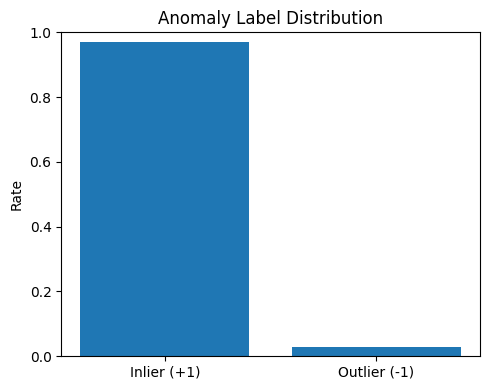

decision_score mean=-25.679087, std=907.083823, min=-41460.404594, max=2.621271


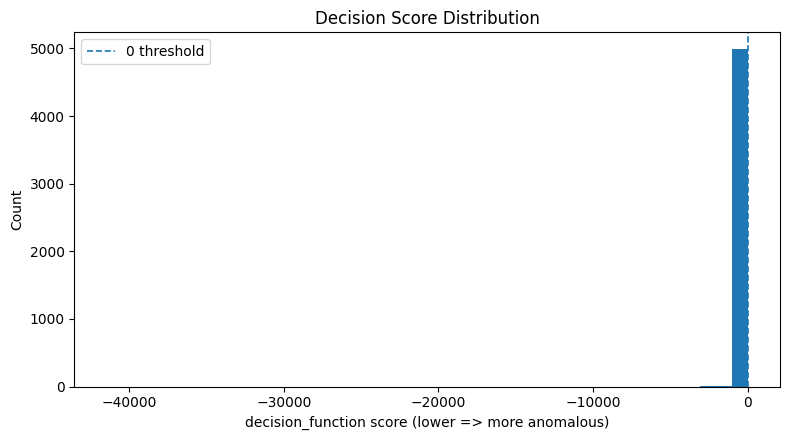

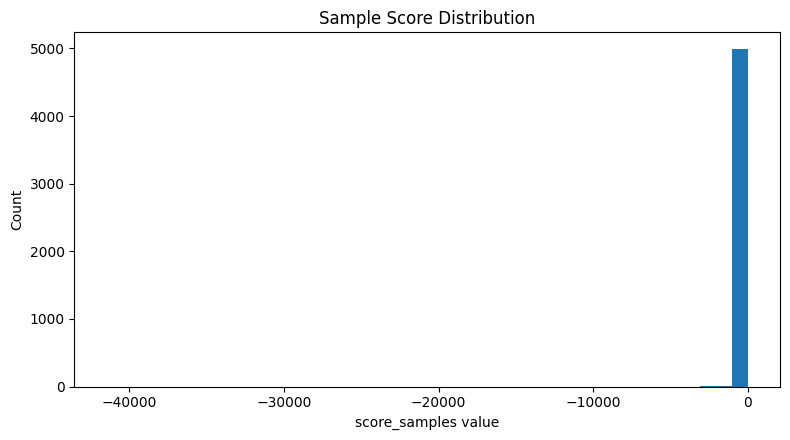

In [7]:
# Diagnostics + diagrams for anomaly score behavior (full_dataset)
if 'INFER_MODEL' not in globals():
    print('Run setup cell first.')
else:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    try:
        base = globals().get('BASE_DIR', Path.cwd())
        split_dir = base / 'splits' / 'full_dataset'
        x_test_csv = split_dir / 'X_test.csv'

        if not x_test_csv.exists():
            raise FileNotFoundError(f'X_test.csv not found at: {x_test_csv}')

        # Load saved test split
        X_eval_df = pd.read_csv(x_test_csv)

        # Match feature count expected by saved model
        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None:
            if X_eval_df.shape[1] > int(expected_n):
                X_eval_df = X_eval_df.iloc[:, :int(expected_n)]
            elif X_eval_df.shape[1] < int(expected_n):
                raise ValueError(
                    f'Feature mismatch: model expects {int(expected_n)} columns, '
                    f'but X_test.csv has {X_eval_df.shape[1]}'
                )

        X_eval = X_eval_df.values

        n = min(5000, X_eval.shape[0])
        X_sub = X_eval[:n]

        preds = INFER_MODEL.predict(X_sub)
        outlier_rate = float((preds == -1).mean())
        inlier_rate = 1.0 - outlier_rate

        print(f'Samples evaluated: {n}')
        print(f'Outlier rate: {outlier_rate:.4f}')
        print(f'Inlier rate: {inlier_rate:.4f}')

        # Mapping used in this notebook: +1(inlier)=ATTACK, -1(outlier)=NORMAL
        attack_rate = inlier_rate
        normal_rate = outlier_rate
        print(f'Attack rate (mapped): {attack_rate:.4f}')
        print(f'Normal rate (mapped): {normal_rate:.4f}')

        # Graph 1
        plt.figure(figsize=(5, 4))
        plt.bar(['Inlier (+1)', 'Outlier (-1)'], [inlier_rate, outlier_rate])
        plt.ylim(0, 1)
        plt.title('Anomaly Label Distribution')
        plt.ylabel('Rate')
        plt.tight_layout()
        plt.show()

        # Graph 2
        if hasattr(INFER_MODEL, 'decision_function'):
            d = np.ravel(INFER_MODEL.decision_function(X_sub))
            print(
                f'decision_score mean={float(d.mean()):.6f}, '
                f'std={float(d.std()):.6f}, '
                f'min={float(d.min()):.6f}, '
                f'max={float(d.max()):.6f}'
            )

            plt.figure(figsize=(8, 4.5))
            plt.hist(d, bins=40)
            plt.axvline(0.0, linestyle='--', linewidth=1.2, label='0 threshold')
            plt.title('Decision Score Distribution')
            plt.xlabel('decision_function score (lower => more anomalous)')
            plt.ylabel('Count')
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Graph 3
        if hasattr(INFER_MODEL, 'score_samples'):
            s = np.ravel(INFER_MODEL.score_samples(X_sub))
            plt.figure(figsize=(8, 4.5))
            plt.hist(s, bins=40)
            plt.title('Sample Score Distribution')
            plt.xlabel('score_samples value')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print('Diagnostics failed:')
        print(str(e))